In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import optimizers
import keras_cv
import numpy as np
from keras_cv import bounding_box
import os
import resource
from keras_cv import visualization
import tqdm
import json

I0000 00:00:1788400295.650515 2905956 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788400295.725078 2905956 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788400301.352632 2905956 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/sanjnasuresh_umass_edu/.conda/envs/driving-clip/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
annotation_file = "driving_dataset_2k/_annotations.coco.json"

with open(annotation_file, "r") as f:
    j = json.load(f)

In [3]:
class_mapping = {c['id']: c['name'] for c in j['categories']}
class_mapping

{0: 'obstacles',
 1: 'biker',
 2: 'car',
 3: 'pedestrian',
 4: 'trafficLight',
 5: 'trafficLight-Green',
 6: 'trafficLight-GreenLeft',
 7: 'trafficLight-Red',
 8: 'trafficLight-RedLeft',
 9: 'trafficLight-Yellow',
 10: 'trafficLight-YellowLeft',
 11: 'truck'}

In [4]:
image_paths = [f"driving_dataset_2k/{d['file_name']}" for d in j['images']]

In [5]:
len(image_paths)

2000

In [6]:
print("Number of images:", len(image_paths))

image_ids = [a["image_id"] for a in j["annotations"]]

print("Min image_id:", min(image_ids))
print("Max image_id:", max(image_ids))
print("First 20 image_ids:", image_ids[:20])

Number of images: 2000
Min image_id: 13
Max image_id: 29798
First 20 image_ids: [13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 18, 37, 37, 37, 37, 37, 37]


In [7]:
# Build ordered image paths from COCO metadata
image_paths = [    f"driving_dataset_2k/{img['file_name']}"
 for img in j["images"]]

# Map COCO image_id -> position in image_paths/classes/bounding_boxes
image_id_to_idx = {
    img["id"]: i
    for i, img in enumerate(j["images"])
}

classes = [[] for _ in image_paths]
bounding_boxes = [[] for _ in image_paths]

for a in j["annotations"]:
    idx = image_id_to_idx[a["image_id"]]

    classes[idx].append(a["category_id"])
    bounding_boxes[idx].append(a["bbox"])

In [8]:
classes[:5]

[[2, 2, 2, 2, 2, 2, 7, 2, 2, 7],
 [3, 3, 2, 2],
 [2, 2],
 [2, 5, 5, 2, 2],
 [2, 2, 2, 2, 2]]

In [9]:
no_annotations = [len(x) == 0 for x in classes]

In [10]:
np.sum(no_annotations)

np.int64(225)

In [11]:
len(image_paths)

2000

In [12]:
bbox = tf.ragged.constant(bounding_boxes)
classes = tf.ragged.constant(classes)
image_paths = tf.ragged.constant(image_paths)

data = tf.data.Dataset.from_tensor_slices((image_paths, classes, bbox))

E0000 00:00:1788400335.261813 2905956 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
E0000 00:00:1788400335.285207 2905956 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1788400335.295274 2905956 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [13]:
len(data)

2000

In [14]:
smalldata = data.take(100)

In [15]:
len(smalldata)

100

In [16]:
val_data = smalldata.take(30)
train_data = smalldata.skip(30)

In [17]:
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    return image


def load_dataset(image_path, classes, bbox):
    # Read Image
    image = load_image(image_path)
    bounding_boxes = {
        "classes": tf.cast(classes, dtype=tf.float32),
        "boxes": bbox,
    }
    return {
        "images": tf.cast(image, tf.float32), "bounding_boxes": bounding_boxes}

In [18]:
BATCH_SIZE = 4

In [19]:
augmenter = keras.Sequential(
    layers=[
        keras_cv.layers.RandomFlip(
            mode="horizontal", bounding_box_format="xywh"),
        keras_cv.layers.RandomShear(
            x_factor=0.2, y_factor=0.2, bounding_box_format="xywh"
        ),
        keras_cv.layers.JitteredResize(
            target_size=(640, 640),
            scale_factor=(0.75, 1.3),
            bounding_box_format="xywh"
        ),
    ]
)

In [20]:
# Create train dataset
train_ds = train_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(BATCH_SIZE * 4)
train_ds = train_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
train_ds = train_ds.map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)

In [21]:
# Create validation dataset
resizing = keras_cv.layers.Resizing(
    640, 640, bounding_box_format="xywh", pad_to_aspect_ratio=True
)

val_ds = val_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.shuffle(BATCH_SIZE * 4)
val_ds = val_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
val_ds = val_ds.map(resizing, num_parallel_calls=tf.data.AUTOTUNE)

In [22]:
def visualize_dataset(inputs, value_range, rows, cols, bounding_box_format):
    inputs = next(iter(inputs.take(1)))
    images, bounding_boxes = inputs["images"], inputs["bounding_boxes"]
    visualization.plot_bounding_box_gallery(
        images,
        value_range=value_range,
        rows=rows,
        cols=cols,
        y_true=bounding_boxes,
        scale=5,
        font_scale=0.7,
        bounding_box_format=bounding_box_format,
        class_mapping=class_mapping,
    )

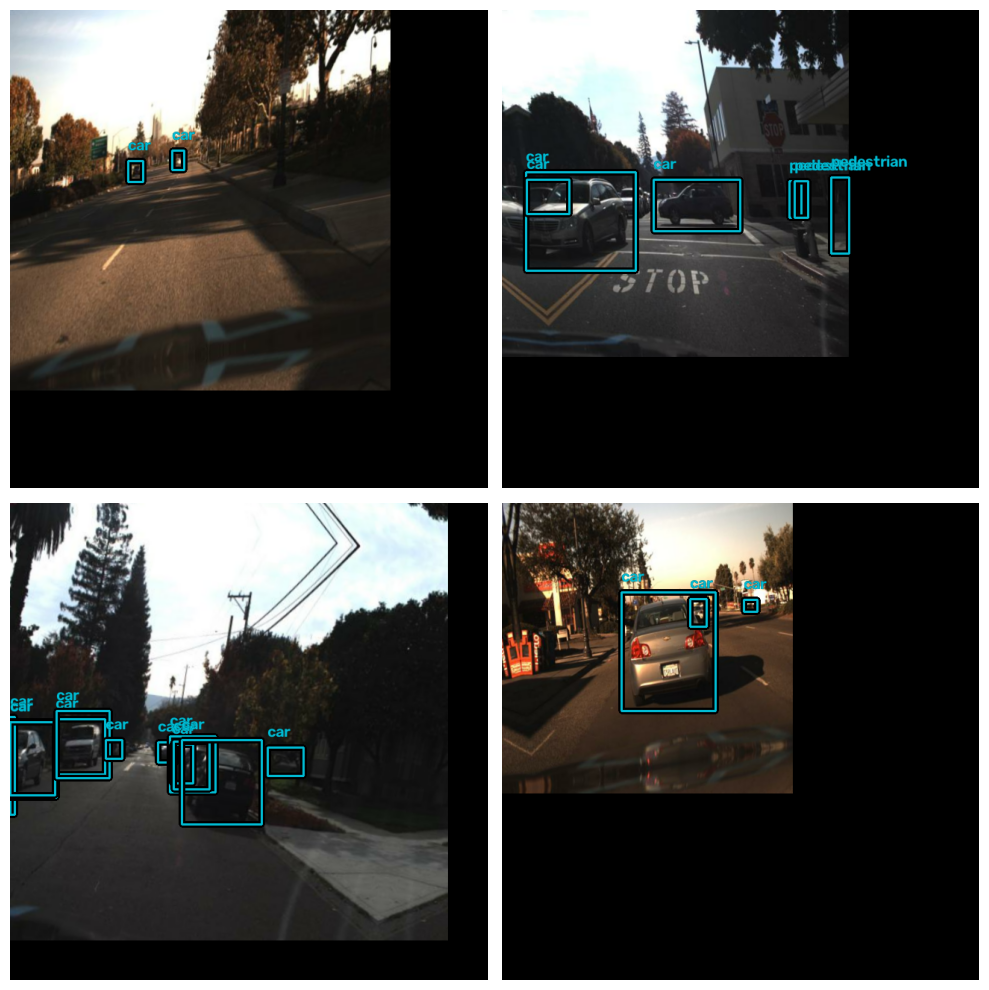

In [23]:
visualize_dataset(
    train_ds, bounding_box_format="xywh", value_range=(0, 255), rows=2, cols=2
)

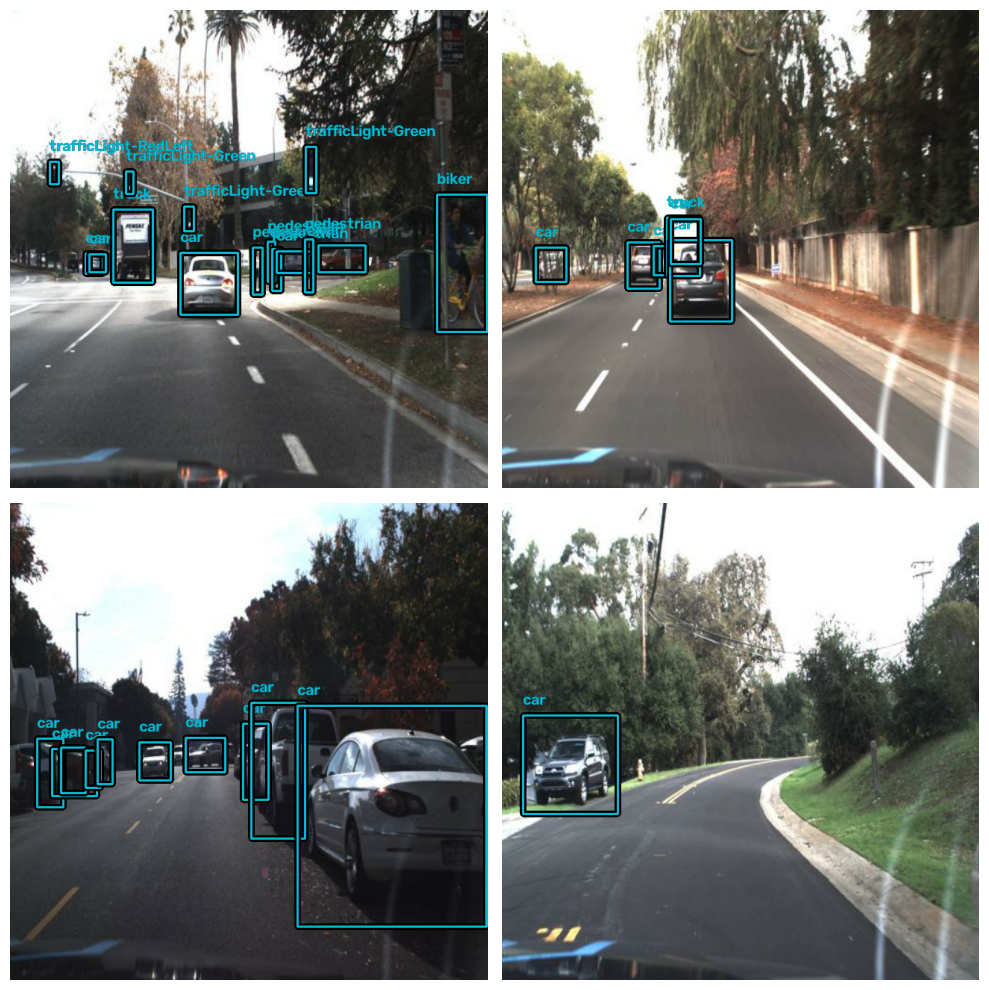

In [24]:
visualize_dataset(
    val_ds, bounding_box_format="xywh", value_range=(0, 255), rows=2, cols=2
)

In [25]:
def dict_to_tuple(inputs):
    return inputs["images"], bounding_box.to_dense(
        inputs["bounding_boxes"], max_boxes=32
    )


train_ds = train_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [26]:
# Global clipnorm helps to reduce exploding gradient

base_lr = 0.005
# including a global_clipnorm is extremely important in object detection tasks
optimizer = tf.keras.optimizers.SGD(
    learning_rate=base_lr, momentum=0.9, global_clipnorm=10.0
)

In [27]:
# Creates a "RetinaNet" from ResNet50 backbone

model = keras_cv.models.RetinaNet.from_preset(
    "resnet50_imagenet",
    num_classes=len(class_mapping),
    bounding_box_format="xywh",
)

In [28]:
model.compile(
    classification_loss="focal",
    box_loss="smoothl1",
    optimizer=optimizer,
)

In [29]:
model.fit(
    train_ds.take(20),
    validation_data=val_ds.take(20),
    epochs=3,
)

Epoch 1/3


/home/sanjnasuresh_umass_edu/.conda/envs/driving-clip/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
/home/sanjnasuresh_umass_edu/.conda/envs/driving-clip/lib/python3.11/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(4, 640, 640, 3))
  warnings.warn(msg)


17/17 ━━━━━━━━━━━━━━━━━━━━ 324s 18s/step - box_loss: 0.6782 - classification_loss: 0.8515 - loss: 1.5297 - percent_boxes_matched_with_anchor: 0.7960 - val_box_loss: 0.6679 - val_classification_loss: 0.7110 - val_loss: 1.3789 - val_percent_boxes_matched_with_anchor: 0.8359
Epoch 2/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 289s 17s/step - box_loss: 0.6280 - classification_loss: 0.6614 - loss: 1.2894 - percent_boxes_matched_with_anchor: 0.7927 - val_box_loss: 0.6453 - val_classification_loss: 0.6789 - val_loss: 1.3242 - val_percent_boxes_matched_with_anchor: 0.8292
Epoch 3/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 284s 17s/step - box_loss: 0.6075 - classification_loss: 0.6687 - loss: 1.2762 - percent_boxes_matched_with_anchor: 0.7937 - val_box_loss: 0.6308 - val_classification_loss: 0.6669 - val_loss: 1.2977 - val_percent_boxes_matched_with_anchor: 0.8315


In [31]:
model.save_weights("retinanet_resnet50.weights.h5")

In [32]:
# Let's create a simple function to plot our inferences
def visualize_detections(model, dataset, bounding_box_format):
    images, y_true = next(iter(dataset.take(1)))
    y_pred = model.predict(images)
    y_pred = bounding_box.to_ragged(y_pred)
    visualization.plot_bounding_box_gallery(
        images,
        value_range=(0, 255),
        bounding_box_format=bounding_box_format,
        y_true=y_true,
        y_pred=y_pred,
        scale=4,
        rows=4,
        cols=2,
        show=True,
        font_scale=0.7,
        class_mapping=class_mapping,
    )

In [33]:
# Set IoU and confidence threshold
model.prediction_decoder = keras_cv.layers.MultiClassNonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,
    iou_threshold=0.5,
    confidence_threshold=0.2,
)

In [34]:
# construct a dataset with larger batches:
visualization_ds = val_ds.unbatch()
visualization_ds = visualization_ds.ragged_batch(16)
visualization_ds = visualization_ds.shuffle(8)

In [35]:
# construct a dataset with larger batches:
visualization_ds = val_ds.unbatch()
visualization_ds = visualization_ds.ragged_batch(16)
visualization_ds = visualization_ds.shuffle(8)